In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('/kaggle/input/digital-currency-time-series/dc.csv')
df.head()

,Unnamed: 0,open_SAR,open_USD,high_SAR,high_USD,low_SAR,low_USD,close_SAR,close_USD,volume
0,2021-01-30,128437.248512,34246.28,131012.723200,34933.00,123106.880000,32825.00,128333.212416,34218.54,43072
1,2021-01-29,125144.022272,33368.18,144510.037760,38531.90,119695.516160,31915.40,128459.450880,34252.20,231827
2,2021-01-28,113870.357376,30362.19,126703.438592,33783.98,111919.811840,29842.10,125131.570944,33364.86,92621
3,2021-01-27,121753.023104,32464.01,122102.860416,32557.29,109668.146688,29241.72,113885.208960,30366.15,95911
4,2021-01-26,120966.114176,32254.19,123470.218752,32921.88,115652.472448,30837.37,121767.124608,32467.77,84972


In [2]:
df.rename(columns={df.iloc[:,0].name:'Date'}, inplace=True)

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index(df['Date'], drop=True, inplace=True)
df.sort_index(ascending=True, inplace=True)
to_drop = list(df.columns)
to_drop.remove('close_SAR'); to_drop.remove('close_USD')
df.drop(to_drop, axis=1, inplace=True)
df.head()

,close_SAR,close_USD
Date,,
2018-05-07,35122.496000,9365.00
2018-05-08,34457.025024,9187.56
2018-05-09,34916.224000,9310.00
2018-05-10,33761.850880,9002.20
2018-05-11,31503.360000,8400.00


In [4]:
# Display close SAR trending..
import plotly.express as px
%matplotlib inline
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')

fig = px.line(df, x=df.index, y=['close_USD', 'close_SAR'], labels={'values':'Bitcoin values', 'index':'Date Time'})
fig.update_layout(height=500, width=1200)
fig.update_traces(line={'width':1.4})
fig.data[0].line.color = 'red'
fig.data[1].line.color = 'green'
fig.show()

In [5]:
df_sar = df.copy().drop(['close_USD'], axis=1)
df_usd = df.copy().drop(['close_SAR'], axis=1)

# Create sequence features by sliding window....
n = 50
seq, target = [], []
for i in range(n, df_sar.shape[0]):
    seq.append(df_sar.iloc[i-n:i, 0])
    target.append(df_sar.iloc[i, 0])

seq = np.array(seq)                              ## 50 features depends on 50 samples previously for sliding window.
target = np.array(target).reshape(-1,1)

In [7]:
# Splitting data...
from sklearn.model_selection import train_test_split
import sklearn
import xgboost

X_train, X_test, y_train, y_test = train_test_split(seq, target, test_size=.3, shuffle=False, random_state=42)

#  Scaling..
X_sc = sklearn.preprocessing.MinMaxScaler()
X_train_sc = X_sc.fit_transform(X_train)
X_test_sc = X_sc.transform(X_test)

# Implement models...
models = dict(
    LR = sklearn.linear_model.LinearRegression(),
    SGDR = sklearn.linear_model.SGDRegressor(max_iter=5000, learning_rate='constant', eta0=0.01),
    KNNR = sklearn.neighbors.KNeighborsRegressor(n_neighbors=10),
    SVR = sklearn.svm.SVR(kernel='linear', C=10),
    RFR = sklearn.ensemble.RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    XGBR = xgboost.XGBRegressor()
)

# Evaluate nodel...
preds = []
metrics = {}
mae_list, r2_list = [], []
for i, (prototype, model) in enumerate(models.items()):
    model.fit(X_train_sc, y_train.ravel())
    # Prediction process...
    y_pred = model.predict(X_test_sc)
    preds.append(y_pred)

    mae_list.append(round(sklearn.metrics.mean_absolute_error(y_test, y_pred), 2))
    r2_list.append(round((sklearn.metrics.r2_score(y_test, y_pred))*100, 2))
    metrics['MAE'] = mae_list
    metrics['R score'] = r2_list 
    print(f'{i+1}. {prototype} Model:')
    print(f'RMSE: {metrics['MAE'][i]}')
    print(f'R score: {metrics['R score'][i]}')
    print('-'*30)

1. LR Model:
RMSE: 1652.77
R score: 99.06
------------------------------
2. SGDR Model:
RMSE: 1733.71
R score: 98.86
------------------------------
3. KNNR Model:
RMSE: 18957.26
R score: -24.66
------------------------------
4. SVR Model:
RMSE: 13323.52
R score: 55.79
------------------------------
5. RFR Model:
RMSE: 17154.9
R score: -20.74
------------------------------
6. XGBR Model:
RMSE: 17894.96
R score: -31.21
------------------------------


Best models : Linear Regression & Stochastic Gradient Descent Regressor

Bad models  :
1. KNN >> depend on euclidean or manhattan discances as a metric, it is good for clustered data and which target data are nearest with each other, but our data arn't that!
2. SVR >> need scaling for target 'y' and tuning hyperparameter C then become good regressor.
3. RFR & XGBR >> are good regressors with classification data or non-linear patterns, and arn't needs any scaling..

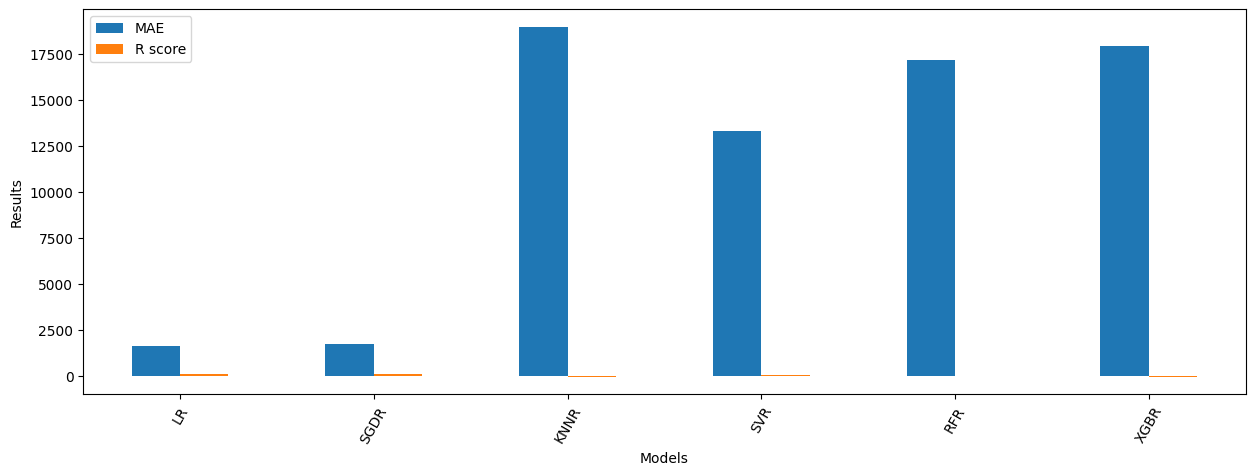

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = pd.DataFrame(metrics, index=models.keys())

metrics.plot(kind='bar', figsize=(15, 5))
plt.xlabel('Models')
plt.ylabel('Results')
plt.xticks(rotation=60)
plt.show()

In [9]:
# Assign test indeces..
test_index = df.index[n + len(X_train): ]
# Plotting test time series for best models prediction...
fig = px.line(x=test_index, y=[y_test.ravel(), preds[0].ravel(), preds[1].ravel()],
              labels={'values':'Predictions', 'index':'Date Time'})
fig.update_layout(height=500, width=1300, title='Bitcoin price by close SAR using LR & SGDR')
fig.update_traces(line={'width':2})
fig.data[0].line.color = 'green'
fig.data[1].line.color = 'red'
fig.data[2].line.color = 'blue'
fig.show()

In [10]:
report = dict(Actual = y_test.ravel(),
              LR_Prediction = preds[0],
              SGD_Prediction = preds[1])
report = pd.DataFrame(report, index=test_index)
print('✅Submission Completed..\n')
report

✅Submission Completed..



,Actual,LR_Prediction,SGD_Prediction
Date,,,
2020-04-21,25657.874048,25116.275157,25736.315849
2020-04-22,26722.125056,24494.903155,25161.395196
2020-04-23,28061.955456,26985.017773,25473.692106
2020-04-24,28146.752000,26588.309833,26152.173746
2020-04-25,28273.027968,27993.578668,26835.651764
...,...,...,...
2021-01-26,121767.124608,119165.442831,119471.832628
2021-01-27,113885.208960,117710.624255,119455.868776
2021-01-28,125131.570944,112051.686665,116389.606189
